
# Fine-tuning a Pretrained Vision Transformer (ViT) on the Oxford-IIIT Pet Dataset

## 0. Setup

In [1]:

import os
import time
import random

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import vit_b_16, ViT_B_16_Weights

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print("Using device:", device, "| visible GPUs:", num_gpus)
if num_gpus > 1:
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Using device: cuda | visible GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 1. Config

In [2]:

class Config:
    # --- data ---
    data_root = "./data"   # Oxford-IIIT Pet download

    # --- pretrained model ---
    model_name = "facebook/vit-mae-base"
                                 

    # two-stage fine-tuning schedule
    batch_size = 32              
    epochs_head = 5                
    epochs_finetune = 10           
    lr_head = 1e-3                 
    lr_finetune = 1e-5              
                                    
    weight_decay = 1e-4
    use_amp = True                 

    checkpoint_dir = "./checkpoints"
    best_model_path = "./vit_finetuned_best.pth"
    final_model_path = "./vit_finetuned_final.pth"

cfg = Config()
os.makedirs(cfg.checkpoint_dir, exist_ok=True)



## 2. Data — Oxford-IIIT Pet Dataset

Downloads automatically on first run (~800MB). It ships with two splits,
which map directly onto what we need:

- `"trainval"` (~3,680 images) — used for training
- `"test"` (~3,670 images) — used as our validation/held-out set


In [3]:

weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess = weights.transforms()   # correct resize/crop/normalize for this exact pretrained model

# Light augmentation on top of the required preprocessing.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=preprocess.mean, std=preprocess.std),
])
eval_transform = preprocess

train_dataset = OxfordIIITPet(root=cfg.data_root, split="trainval", target_types="category",
                               transform=train_transform, download=True)
val_dataset = OxfordIIITPet(root=cfg.data_root, split="test", target_types="category",
                             transform=eval_transform, download=True)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"{num_classes} pet breeds: {class_names}")
print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                           num_workers=4, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=4, pin_memory=(device.type == "cuda"))


100%|██████████| 792M/792M [00:50<00:00, 15.7MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.6MB/s]


37 pet breeds: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
Train: 3680 images | Val: 3669 images



## 3. Load the pretrained ViT and swap in your classifier head


In [4]:

model = vit_b_16(weights=weights)

in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)
model = model.to(device)

if num_gpus > 1:
    model = nn.DataParallel(model)
    print(f"nn.DataParallel active — using all {num_gpus} GPUs.")

def raw(m):
    return m.module if isinstance(m, nn.DataParallel) else m

n_params = sum(p.numel() for p in raw(model).parameters())
print(f"Model has {n_params/1e6:.1f}M parameters, head replaced for {num_classes} classes.")


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 185MB/s] 


nn.DataParallel active — using all 2 GPUs.
Model has 85.8M parameters, head replaced for 37 classes.



## 4. Training / evaluation helpers


In [5]:

scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and device.type == "cuda"))
criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device.type == "cuda")):
                logits = model(imgs)
                loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total


def fine_tune(model, epochs, lr, stage_name):
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=cfg.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = -1.0
    history = []

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)
        scheduler.step()
        dt = time.time() - t0

        history.append((train_loss, train_acc, val_loss, val_acc))
        print(f"[{stage_name}] epoch {epoch+1}/{epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} ({dt:.1f}s)")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(raw(model).state_dict(), cfg.best_model_path)
            print(f"  -> new best val_acc={best_val_acc:.4f}, saved to {cfg.best_model_path}")

        torch.save({
            "epoch": epoch,
            "stage": stage_name,
            "model_state_dict": raw(model).state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "class_names": class_names,
        }, os.path.join(cfg.checkpoint_dir, f"{stage_name}_epoch_{epoch+1}.pth"))

    return history


/tmp/ipykernel_58/4237538792.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and device.type == "cuda"))



## 5. Stage 1 — train the new head only



In [6]:

for p in raw(model).parameters():
    p.requires_grad = False
for p in raw(model).heads.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in raw(model).parameters() if p.requires_grad)
print(f"Stage 1: {trainable} trainable parameters (head only).")

history_stage1 = fine_tune(model, cfg.epochs_head, cfg.lr_head, stage_name="stage1_head")


Stage 1: 28453 trainable parameters (head only).


/tmp/ipykernel_58/4237538792.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device.type == "cuda")):


[stage1_head] epoch 1/5 train_loss=0.9161 train_acc=0.8326 val_loss=0.3171 val_acc=0.9199 (28.7s)
  -> new best val_acc=0.9199, saved to ./vit_finetuned_best.pth
[stage1_head] epoch 2/5 train_loss=0.2239 train_acc=0.9465 val_loss=0.2592 val_acc=0.9231 (26.7s)
  -> new best val_acc=0.9231, saved to ./vit_finetuned_best.pth
[stage1_head] epoch 3/5 train_loss=0.1534 train_acc=0.9658 val_loss=0.2417 val_acc=0.9280 (28.0s)
  -> new best val_acc=0.9280, saved to ./vit_finetuned_best.pth
[stage1_head] epoch 4/5 train_loss=0.1237 train_acc=0.9761 val_loss=0.2309 val_acc=0.9302 (27.2s)
  -> new best val_acc=0.9302, saved to ./vit_finetuned_best.pth
[stage1_head] epoch 5/5 train_loss=0.1137 train_acc=0.9774 val_loss=0.2293 val_acc=0.9319 (27.0s)
  -> new best val_acc=0.9319, saved to ./vit_finetuned_best.pth



## 6. Stage 2 — unfreeze everything, fine-tune end-to-end




In [7]:

for p in raw(model).parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in raw(model).parameters() if p.requires_grad)
print(f"Stage 2: {trainable} trainable parameters (full model).")

history_stage2 = fine_tune(model, cfg.epochs_finetune, cfg.lr_finetune, stage_name="stage2_finetune")

torch.save(raw(model).state_dict(), cfg.final_model_path)
print(f"Final fine-tuned model saved to: {cfg.final_model_path}")
print(f"Best model by val accuracy saved to: {cfg.best_model_path}")


Stage 2: 85827109 trainable parameters (full model).


/tmp/ipykernel_58/4237538792.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device.type == "cuda")):


[stage2_finetune] epoch 1/10 train_loss=0.0996 train_acc=0.9742 val_loss=0.2004 val_acc=0.9379 (41.5s)
  -> new best val_acc=0.9379, saved to ./vit_finetuned_best.pth
[stage2_finetune] epoch 2/10 train_loss=0.0515 train_acc=0.9894 val_loss=0.1918 val_acc=0.9398 (41.5s)
  -> new best val_acc=0.9398, saved to ./vit_finetuned_best.pth
[stage2_finetune] epoch 3/10 train_loss=0.0264 train_acc=0.9989 val_loss=0.1921 val_acc=0.9357 (41.5s)
[stage2_finetune] epoch 4/10 train_loss=0.0182 train_acc=0.9986 val_loss=0.1834 val_acc=0.9409 (41.1s)
  -> new best val_acc=0.9409, saved to ./vit_finetuned_best.pth
[stage2_finetune] epoch 5/10 train_loss=0.0126 train_acc=0.9995 val_loss=0.1879 val_acc=0.9414 (41.5s)
  -> new best val_acc=0.9414, saved to ./vit_finetuned_best.pth
[stage2_finetune] epoch 6/10 train_loss=0.0120 train_acc=0.9997 val_loss=0.1878 val_acc=0.9409 (41.7s)
[stage2_finetune] epoch 7/10 train_loss=0.0090 train_acc=0.9997 val_loss=0.1864 val_acc=0.9422 (41.7s)
  -> new best val_acc=0

## 7. Training curves

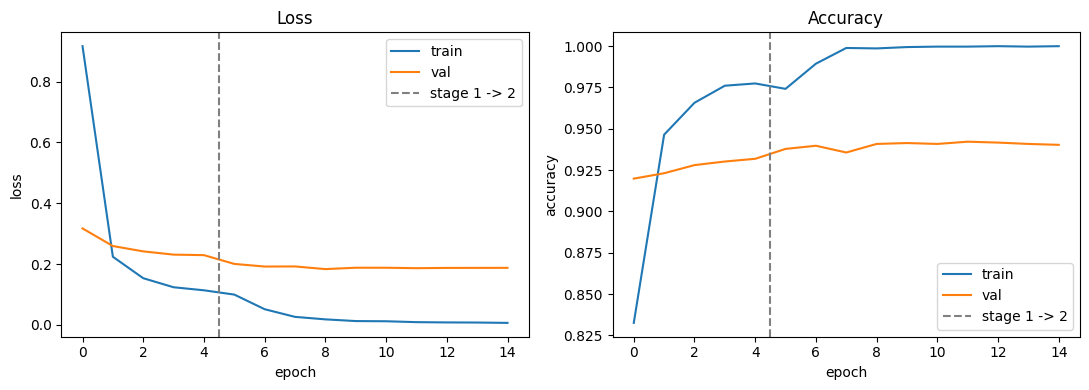

Best validation accuracy: 0.9422


In [8]:

all_history = history_stage1 + history_stage2
train_losses = [h[0] for h in all_history]
train_accs = [h[1] for h in all_history]
val_losses = [h[2] for h in all_history]
val_accs = [h[3] for h in all_history]
stage1_end = len(history_stage1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].axvline(stage1_end - 0.5, color="gray", linestyle="--", label="stage 1 -> 2")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs, label="val")
axes[1].axvline(stage1_end - 0.5, color="gray", linestyle="--", label="stage 1 -> 2")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].set_title("Accuracy")

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(val_accs):.4f}")
